# SCC0276 - Aprendizado de Máquina - EXERCÍCIO 5


# Criando um conjunto de dados sintético

Para os exemplos desta semana, iremos utilizar um [conjunto de dados sintético](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html). Este conjunto de dados corresponde a exemplos com 2 atributos que correspondem a coordenadas X e Y para visualização 2D.

In [14]:
# Importando bibliotecas
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, recall_score, precision_score
import numpy as np

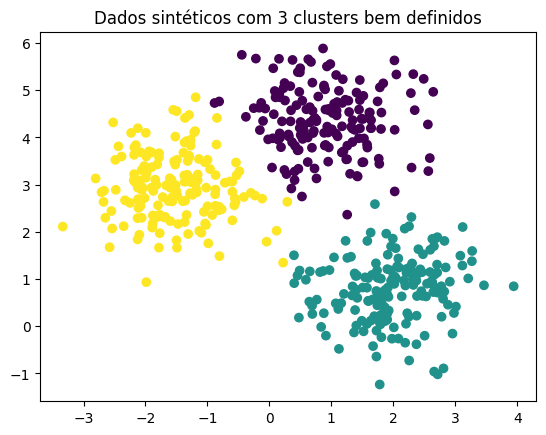

In [5]:
X, y = make_blobs(centers=3, cluster_std=0.7, n_samples=500, random_state=0)

plt.scatter(X[:, 0], X[:, 1], c=y) # colorindo os pontos de acordo com seus rótulos
plt.title("Dados sintéticos com 3 clusters bem definidos")
plt.show()

# 1) K-Vizinhos mais Próximos

Dando prosseguimento para os exercícios, agora iremos avaliar o modelo [KNN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html).

1) Divida o "X" e "y" sintéticos gerados anteriormente em treino e teste. Utilize 20% dos dados para teste, uma divisão estratificada e a *seed* 2026 para gerar os conjuntos.
3) Seguindo a linha de exercícios das semanas anteriores, avalie três variações do KNN com parâmetros diferentes. Armazene os modelos treinados pois eles serão utilizados no próximo exercício. Como métricas, utilize acurácia, precisão e revocação.

In [11]:
# Separando o modelo em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)

# Instanciando modelos
knn1 = KNeighborsClassifier(n_neighbors = 1)
knn2 = KNeighborsClassifier(n_neighbors = 3)
knn3 = KNeighborsClassifier(n_neighbors = 5)

# Treinando modelos
knn1.fit(X_train, y_train)
knn2.fit(X_train, y_train)
knn3.fit(X_train, y_train)

# Realizando previsões
y_pred1 = knn1.predict(X_test)
y_pred2 = knn2.predict(X_test)
y_pred3 = knn3.predict(X_test)

# Avaliando
print(f'Acurácia do KNN com 1 vizinho: {accuracy_score(y_test, y_pred1)}')
print(f'Acurácia do KNN com 3 vizinhos: {accuracy_score(y_test, y_pred2)}')
print(f'Acurácia do KNN com 5 vizinhos: {accuracy_score(y_test, y_pred3)}')

Acurácia do KNN com 1 vizinho: 0.98
Acurácia do KNN com 3 vizinhos: 0.99
Acurácia do KNN com 5 vizinhos: 1.0


# 2) K-Médias

O objetivo deste exercício é avaliar o algoritmo de agrupamento [K-Médias](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).

1) Avalie K-Médias, variando o K de 1 a 10. Configure a *seed* do modelo para 2026. Armazene a inércia de cada modelo (armazenado na variável '*inertia_*') em uma lista para análise no próximo item.
2) Visualize as inércias de cada K em um gráfico de linha. O eixo Y deve corresponder aos valores de inércia. O eixo X deve corresponder aos valores K testados.
3) Usando o conceito da regra do cotovelo (["*Elbow rule*"](https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/)), identifique o número ideal de clusters (valor K).
4) Visualize os agrupamentos gerados adaptando o código de visualização usado acima. Utilize clusters preditos pelo melhor K-Means (usando o melhor K), como parâmetro "c" do "*plt.scatter*". Use oos dados sem pré-processamento para a visualização.


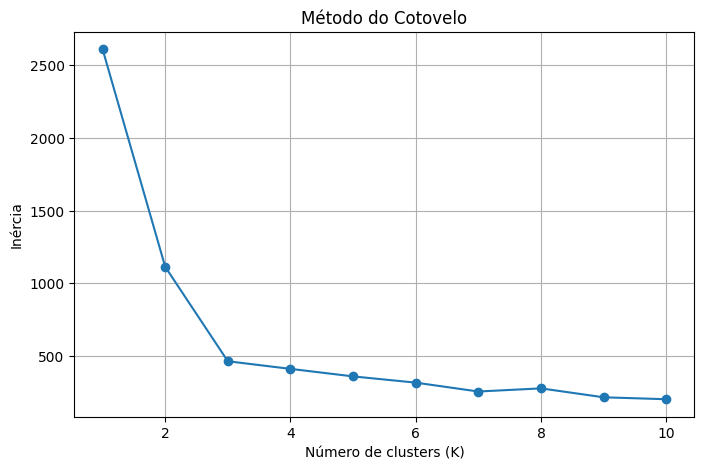

In [19]:
# Lista para armazenar inercias
inertias = []

# For para iterar de 1 a 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state = 2026)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Numero de k-vizinhos para a escala
ks = range(1, 11)

# Plotando gráfico
plt.figure(figsize=(8,5))
plt.plot(ks, inertias, marker='o')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.grid(True)
plt.show()


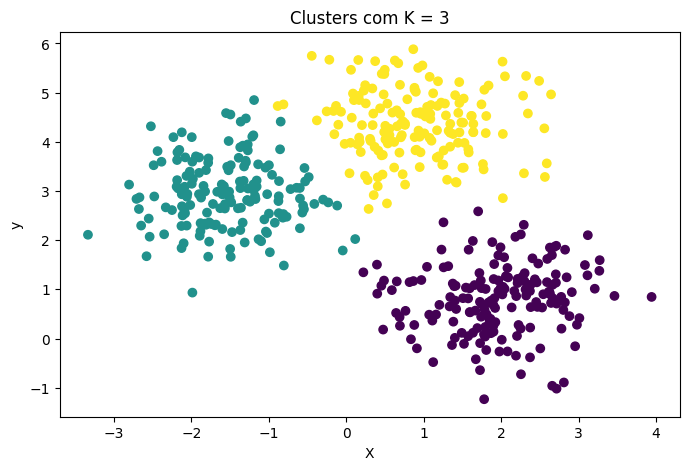

In [13]:
# Utilizando o melhor k de acordo com a regra do cotovelo
best_k = 3

# Instanciando modelo com melhor K
kmeans = KMeans(n_clusters = best_k, random_state = 2026)
kmeans.fit(X)

labels = kmeans.labels_

# Plotando gráfico
plt.figure(figsize=(8,5))
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Clusters com K = {best_k}')

plt.show()

# 3) Avaliar um novo exemplo

O objetivo deste exercício é avaliar um novo exemplo (armazenenado na variável "new_example" a seguir) considerando os modelos KNN treinados no exercicio anterior. Para visualização, o novo exemplo é mostrado como um "ponto vermelho" nos códigos abaixo.

1) Determine para qual classe os KNNs treinados mapeiam o exemplo. Em outras palavras, use os KNNs treinados para predizer a classe do exemplo. Obs: caso a classe não tenha variado, experimente variar o parâmetro K do KNN.
2) Suponha que dois KNNs com valores K distintos tenham classificado o exemplo em classes diferentes. Neste caso, qual classificação você escolheria? Justifique sua resposta.

In [16]:
new_example = np.array([-1, 4.7])

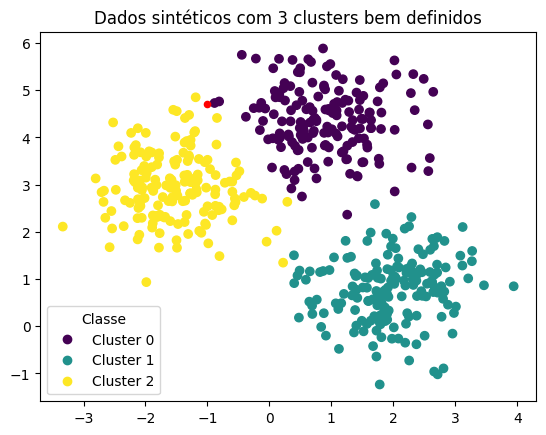

In [22]:
plt.title("Dados sintéticos com 3 clusters bem definidos")
fig = plt.scatter(X[:, 0], X[:, 1], c=y)
# Novo exemplo como um ponto vermelho
plt.scatter(new_example[0], new_example[1], c='red', marker='o', s=20)

handles, _ = fig.legend_elements()
cluster_ids = np.unique(y)
labels = [f"Cluster {i}" for i in cluster_ids]

# Mostrando rotulos para cada classe
plt.legend(handles, labels, title="Classe", loc="best", frameon=True)
# Mostrando rotulos para cada classe
plt.show()

In [20]:
# Realizando a previsão de valores novos
y_pred1 = knn1.predict([new_example])
y_pred2 = knn2.predict([new_example])
y_pred3 = knn3.predict([new_example])

# Printando resultado
print(f'Classificação: {y_pred1}')
print(f'Classificação: {y_pred2}')
print(f'Classificação: {y_pred3}')

Classificação: [0]
Classificação: [0]
Classificação: [2]


# 4) Repita os exercícios para dados reais (opcional)

Repita os exercícios anteriores para algum conjunto de dados de classificação fornecido pelo [sklearn](https://scikit-learn.org/stable/api/sklearn.datasets.html). Note que os exercícios desta semana **não aplicaram nenhum pré-processamento** nos dados sintéticos, para garantir que os comportamentos esperados sejam observados. Quando avaliar dados diferentes, lembre-se de utilizar padronização ou normalização.  

## Questões teóricas para estudo

1. O que é uma medida de distância? Quais propriedades uma função deve satisfazer para ser considerada uma métrica?
2. No contexto de agrupamento, quando se deve utilizar a distância euclidiana? Quando utilizar a distância de cosseno?
3. Explique o problema da maldição da dimensionalidade no contexto de medidas de distância.
4. Descreva como o algoritmo KNN realiza classificação.
5. Como podemos adaptar o KNN para regressão?
6. Por que o KNN é chamado de método “lazy learning”?
7. Descreva o algoritmo do K-Médias.
8. O que representam os centroides do K-Médias?
9. Como a inicialização dos centroides afeta o resultado do K-Médias?



1. Uma medida de distância é uma função que quantifica o grau de dissimilaridade entre dois pontos em um espaço. Para ser considerada uma métrica, a função deve satisfazer quatro propriedades: não negatividade (a distância nunca é negativa), identidade (a distância é zero apenas entre elementos idênticos), simetria (a distância de A para B é igual à de B para A) e desigualdade triangular (o caminho direto entre dois pontos deve ser menor ou igual a qualquer caminho indireto).

2. A distância euclidiana deve ser utilizada quando os atributos possuem significado geométrico e a magnitude dos valores é relevante, sendo adequada para dados numéricos e contínuos. Já a distância de cosseno deve ser utilizada quando o interesse está na similaridade de direção entre vetores e não em sua magnitude, sendo comum em dados de alta dimensionalidade, como análise de textos e embeddings.

3. A maldição da dimensionalidade ocorre porque, à medida que o número de dimensões aumenta, as distâncias entre os pontos tendem a se tornar mais parecidas, reduzindo a capacidade de diferenciar vizinhos próximos de distantes. Isso prejudica algoritmos baseados em distância, como KNN e K-Médias, tornando a medida de distância menos informativa.

4. O algoritmo KNN (K-Nearest Neighbors) realiza classificação identificando os K vizinhos mais próximos de uma nova amostra com base em uma medida de distância. A classe atribuída ao novo exemplo é geralmente determinada pela votação majoritária entre os vizinhos selecionados.

5. O KNN pode ser adaptado para regressão substituindo a votação majoritária pela média dos valores alvo dos K vizinhos mais próximos. Em alguns casos, pode-se utilizar uma média ponderada, dando maior peso aos vizinhos mais próximos.

6. O KNN é chamado de método “lazy learning” porque ele não constrói explicitamente um modelo durante o treinamento. Em vez disso, ele apenas armazena os dados de treino e realiza o processamento no momento da predição, calculando distâncias para encontrar os vizinhos mais próximos.

7. O algoritmo K-Médias (K-Means) inicia escolhendo K centroides iniciais. Em seguida, cada ponto é atribuído ao centroide mais próximo, formando grupos. Após isso, os centroides são recalculados como a média dos pontos de cada grupo. O processo se repete iterativamente até que os centroides parem de mudar significativamente ou seja atingido um critério de parada.

8. Os centroides do K-Médias representam o centro médio dos pontos pertencentes a um agrupamento, funcionando como representantes dos clusters. Eles são usados para definir a qual grupo cada ponto pertence.

9. A inicialização dos centroides afeta diretamente o resultado do K-Médias porque diferentes pontos iniciais podem levar a diferentes agrupamentos e mínimos locais. Uma má inicialização pode resultar em convergência ruim ou clusters de baixa qualidade, enquanto técnicas como K-Means++ ajudam a escolher centroides iniciais mais adequados e estáveis.